In [1]:
"""
Implementação de modelo XGBoost para detecção de fraudes financeiras
Usando dados normalizados do arquivo fraudTest.csv
CORRIGIDO: early_stopping_rounds deve ser usado no construtor do XGBClassifier
"""

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, confusion_matrix,
                            roc_auc_score, precision_recall_curve, auc,
                            f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')
import joblib

In [2]:
# ============================================
# 1. CARREGAMENTO E PRÉ-PROCESSAMENTO DOS DADOS
# ============================================

print("=" * 50)
print("1. CARREGANDO E PRÉ-PROCESSANDO DADOS")
print("=" * 50)

# Carregar dados
df = pd.read_csv('fraudTest.csv')

# Converter target: -1 (fraude) para 1, 0 (não fraude) permanece 0
df['is_fraud'] = df['is_fraud'].replace({-1: 1, 0: 0})

print(f"Shape original: {df.shape}")
print(f"\nDistribuição da classe target:")
print(df['is_fraud'].value_counts())
print(f"Taxa de fraudes: {(df['is_fraud'].sum() / len(df) * 100):.4f}%")

1. CARREGANDO E PRÉ-PROCESSANDO DADOS
Shape original: (555719, 23)

Distribuição da classe target:
is_fraud
0    553574
1      2145
Name: count, dtype: int64
Taxa de fraudes: 0.3860%


In [3]:
# ============================================
# 2. ENGENHARIA DE FEATURES
# ============================================

print("\n" + "=" * 50)
print("2. ENGENHARIA DE FEATURES")
print("=" * 50)

# 2.1 Extrair features temporais
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hora'] = df['trans_date_trans_time'].dt.hour
df['dia_semana'] = df['trans_date_trans_time'].dt.dayofweek
df['dia_mes'] = df['trans_date_trans_time'].dt.day
df['mes'] = df['trans_date_trans_time'].dt.month

# 2.2 Calcular idade
df['dob'] = pd.to_datetime(df['dob'])
df['idade'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# 2.3 Calcular distância entre cliente e comerciante
# Usando fórmula de Haversine para distância mais precisa
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calcula distância em km usando fórmula de Haversine"""
    R = 6371  # Raio da Terra em km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['distancia_km'] = haversine_distance(
    df['lat'], df['long'],
    df['merch_lat'], df['merch_long']
)

# 2.4 Features de transação por hora (simulando histórico)
# Em produção, usaríamos dados históricos reais
df['amt_log'] = np.log1p(df['amt'])  # Transformação logarítmica


2. ENGENHARIA DE FEATURES


In [4]:
# ============================================
# 3. SELEÇÃO DE FEATURES
# ============================================

print("\n" + "=" * 50)
print("3. SELEÇÃO DE FEATURES")
print("=" * 50)

# Features selecionadas para o modelo
features = [
    # Features numéricas
    'amt', 'amt_log', 'city_pop', 'idade', 'distancia_km',
    'hora', 'dia_semana', 'dia_mes', 'mes',

    # Features categóricas
    'category', 'gender', 'state'
]

# Separar features e target
X = df[features]
y = df['is_fraud']

print(f"Número de features: {len(features)}")
print(f"Shape X: {X.shape}, Shape y: {y.shape}")


3. SELEÇÃO DE FEATURES
Número de features: 12
Shape X: (555719, 12), Shape y: (555719,)


In [5]:
# ============================================
# 4. PRÉ-PROCESSAMENTO E NORMALIZAÇÃO
# ============================================

print("\n" + "=" * 50)
print("4. PRÉ-PROCESSAMENTO E NORMALIZAÇÃO")
print("=" * 50)

# Identificar tipos de features
num_features = ['amt', 'amt_log', 'city_pop', 'idade', 'distancia_km',
                'hora', 'dia_semana', 'dia_mes', 'mes']
cat_features = ['category', 'gender', 'state']

# Criar pipeline de pré-processamento
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

# Aplicar pré-processamento
X_processed = preprocessor.fit_transform(X)

# Obter nomes das features após pré-processamento
num_feature_names = num_features
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)
all_feature_names = list(num_feature_names) + list(cat_feature_names)

print(f"Número de features após one-hot encoding: {len(all_feature_names)}")
print(f"Exemplos de features: {all_feature_names[:5]}...")


4. PRÉ-PROCESSAMENTO E NORMALIZAÇÃO
Número de features após one-hot encoding: 75
Exemplos de features: ['amt', 'amt_log', 'city_pop', 'idade', 'distancia_km']...


In [6]:
# ============================================
# 5. DIVISÃO DOS DADOS
# ============================================

print("\n" + "=" * 50)
print("5. DIVISÃO DOS DADOS")
print("=" * 50)

# Stratified split para manter proporção de fraudes
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"\nDistribuição no treino: {np.bincount(y_train)}")
print(f"Distribuição no teste: {np.bincount(y_test)}")


5. DIVISÃO DOS DADOS
Train shape: (389003, 75)
Test shape: (166716, 75)

Distribuição no treino: [387502   1501]
Distribuição no teste: [166072    644]


In [7]:
# ============================================
# 6. CALCULAR CLASS WEIGHTS (para dados desbalanceados)
# ============================================

print("\n" + "=" * 50)
print("6. CALCULANDO PESOS DAS CLASSES")
print("=" * 50)

# Calcular pesos para lidar com desbalanceamento
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

# Criar dicionário de pesos para XGBoost
weight_dict = {0: class_weights[0], 1: class_weights[1]}

# Calcular scale_pos_weight (alternativa para XGBoost)
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print(f"Pesos das classes: {weight_dict}")
print(f"scale_pos_weight para XGBoost: {scale_pos_weight:.2f}")


6. CALCULANDO PESOS DAS CLASSES
Pesos das classes: {0: np.float64(0.5019367641973461), 1: np.float64(129.58127914723516)}
scale_pos_weight para XGBoost: 258.16


In [8]:
# ============================================
# 7. TREINAMENTO DO MODELO XGBOOST (CORRIGIDO)
# ============================================

print("\n" + "=" * 50)
print("7. TREINANDO MODELO XGBOOST")
print("=" * 50)

# 7.1 Configurar parâmetros do XGBoost
params = {
    'objective': 'binary:logistic',  # Classificação binária
    'eval_metric': 'aucpr',  # AUC-PR é melhor para dados desbalanceados
    'learning_rate': 0.1,  # Taxa de aprendizado
    'max_depth': 6,  # Profundidade máxima das árvores
    'min_child_weight': 1,  # Peso mínimo nas folhas
    'subsample': 0.8,  # Fração de amostras por árvore
    'colsample_bytree': 0.8,  # Fração de features por árvore
    'gamma': 0,  # Redução mínima de loss para split
    'reg_alpha': 0.1,  # Regularização L1
    'reg_lambda': 1,  # Regularização L2
    'scale_pos_weight': scale_pos_weight,  # Peso para classe positiva (fraude)
    'random_state': 42,
    'n_jobs': -1,  # Usar todos os cores
    'verbosity': 0,
    'early_stopping_rounds': 10  # early stopping no construtor
}

print("Parâmetros do XGBoost:")
for key, value in params.items():
    print(f"  {key}: {value}")

# 7.2 Criar e treinar o modelo
print("\nTreinando modelo...")
model = xgb.XGBClassifier(**params)

# Usar eval_set
eval_set = [(X_train, y_train), (X_test, y_test)]

# Treinar o modelo
model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=False  # Mudar para True se quiser ver o progresso
)

print("Treinamento concluído!")

# Verificar se teve early stopping
if hasattr(model, 'best_iteration'):
    print(f"Melhor iteração: {model.best_iteration}")
else:
    print("Treinamento completo sem early stopping")


7. TREINANDO MODELO XGBOOST
Parâmetros do XGBoost:
  objective: binary:logistic
  eval_metric: aucpr
  learning_rate: 0.1
  max_depth: 6
  min_child_weight: 1
  subsample: 0.8
  colsample_bytree: 0.8
  gamma: 0
  reg_alpha: 0.1
  reg_lambda: 1
  scale_pos_weight: 258.16255829447033
  random_state: 42
  n_jobs: -1
  verbosity: 0
  early_stopping_rounds: 10

Treinando modelo...
Treinamento concluído!
Melhor iteração: 95


In [9]:
# ============================================
# 8. AVALIAÇÃO DO MODELO
# ============================================

print("\n" + "=" * 50)
print("8. AVALIAÇÃO DO MODELO")
print("=" * 50)

# 8.1 Fazer previsões
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilidades da classe positiva

# 8.2 Métricas de classificação
print("\nRELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, y_pred, target_names=['Não Fraude', 'Fraude']))

# 8.3 Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print("\nMATRIZ DE CONFUSÃO:")
print(f"[[TN FP]")
print(f" [FN TP]] = ")
print(cm)

# 8.4 Métricas adicionais
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nMÉTRICAS ADICIONAIS:")
print(f"AUC-ROC: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# 8.5 AUC-PR (mais importante para dados desbalanceados)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)
print(f"AUC-PR (Precision-Recall): {pr_auc:.4f}")


8. AVALIAÇÃO DO MODELO

RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

  Não Fraude       1.00      0.99      1.00    166072
      Fraude       0.28      0.96      0.44       644

    accuracy                           0.99    166716
   macro avg       0.64      0.98      0.72    166716
weighted avg       1.00      0.99      0.99    166716


MATRIZ DE CONFUSÃO:
[[TN FP]
 [FN TP]] = 
[[164514   1558]
 [    26    618]]

MÉTRICAS ADICIONAIS:
AUC-ROC: 0.9978
Precision: 0.2840
Recall: 0.9596
F1-Score: 0.4383
AUC-PR (Precision-Recall): 0.8881



9. GERANDO VISUALIZAÇÕES
Métricas disponíveis: ['aucpr']


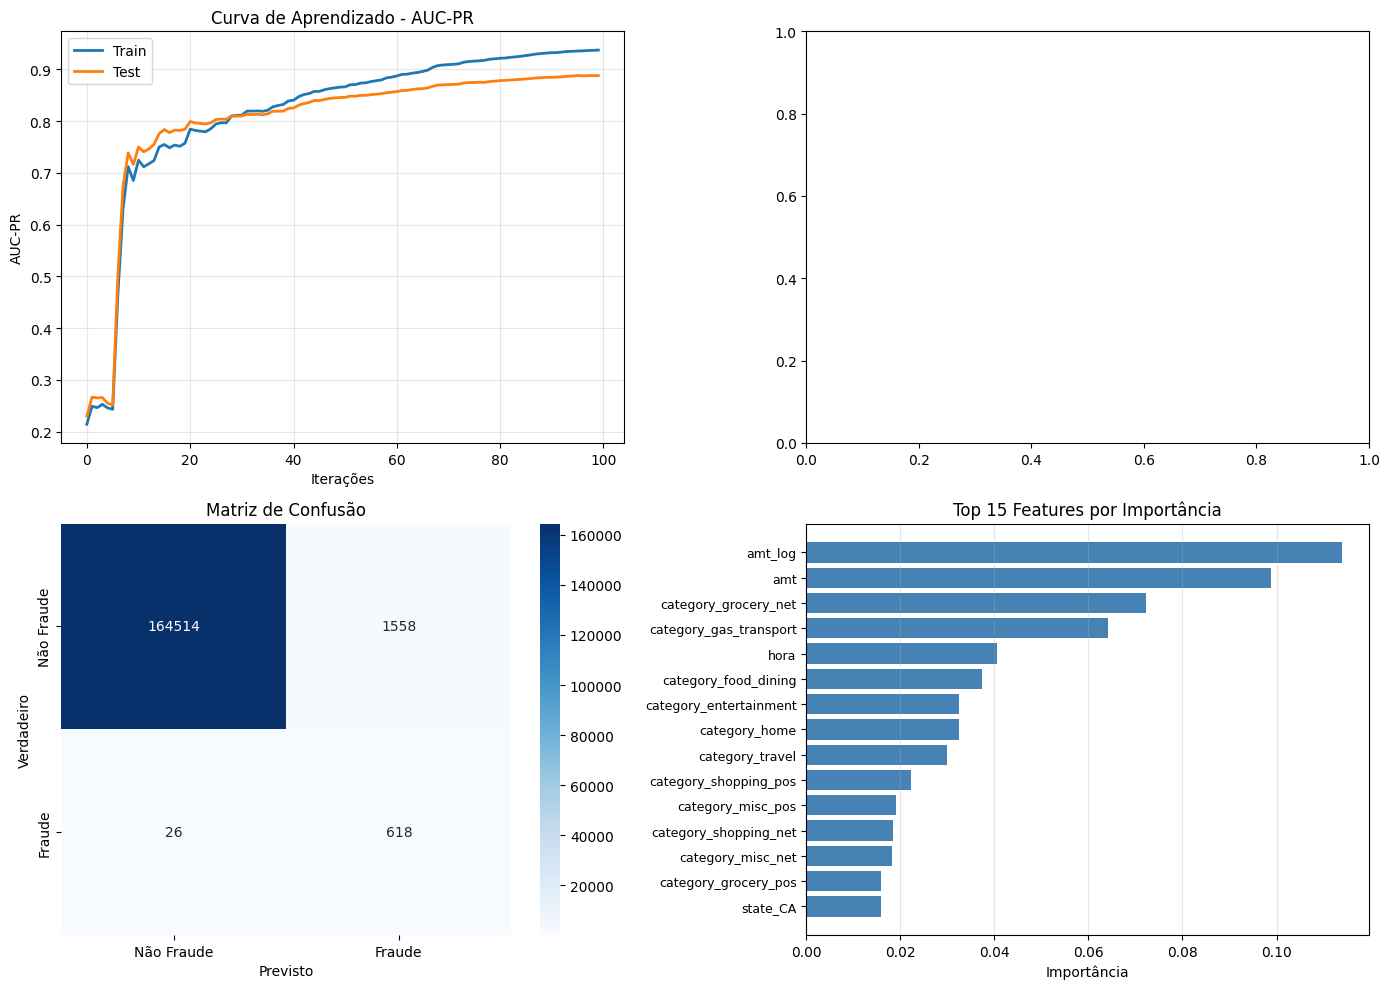

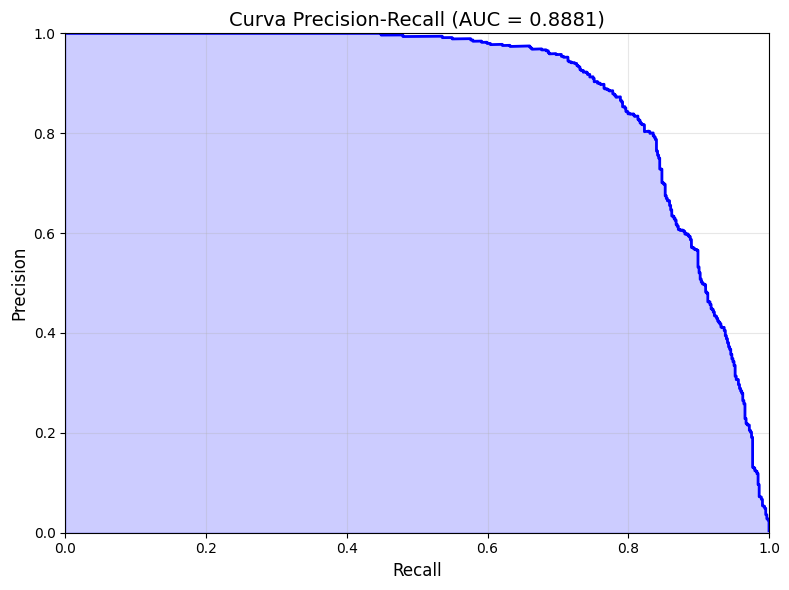

In [10]:
# ============================================
# 9. VISUALIZAÇÕES
# ============================================

print("\n" + "=" * 50)
print("9. GERANDO VISUALIZAÇÕES")
print("=" * 50)

# 9.1 Plotar curva de aprendizado
results = model.evals_result()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Verificar quais métricas estão disponíveis
available_metrics = list(results['validation_0'].keys())
print(f"Métricas disponíveis: {available_metrics}")

if 'aucpr' in available_metrics:
    # Curva de AUC-PR
    epochs = len(results['validation_0']['aucpr'])
    x_axis = range(0, epochs)

    axes[0, 0].plot(x_axis, results['validation_0']['aucpr'], label='Train', linewidth=2)
    axes[0, 0].plot(x_axis, results['validation_1']['aucpr'], label='Test', linewidth=2)
    axes[0, 0].legend()
    axes[0, 0].set_ylabel('AUC-PR')
    axes[0, 0].set_xlabel('Iterações')
    axes[0, 0].set_title('Curva de Aprendizado - AUC-PR')
    axes[0, 0].grid(True, alpha=0.3)

    # Curva de Log Loss se disponível
    if 'logloss' in available_metrics:
        axes[0, 1].plot(x_axis, results['validation_0']['logloss'], label='Train', linewidth=2)
        axes[0, 1].plot(x_axis, results['validation_1']['logloss'], label='Test', linewidth=2)
        axes[0, 1].legend()
        axes[0, 1].set_ylabel('Log Loss')
        axes[0, 1].set_xlabel('Iterações')
        axes[0, 1].set_title('Curva de Aprendizado - Log Loss')
        axes[0, 1].grid(True, alpha=0.3)

# 9.2 Plotar matriz de confusão
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Fraude', 'Fraude'],
            yticklabels=['Não Fraude', 'Fraude'], ax=axes[1, 0])
axes[1, 0].set_title('Matriz de Confusão')
axes[1, 0].set_ylabel('Verdadeiro')
axes[1, 0].set_xlabel('Previsto')

# 9.3 Plotar importância das features
importances = model.feature_importances_
# Pegar top 15 features ou menos se não houver muitas
top_n = min(15, len(importances))
indices = np.argsort(importances)[-top_n:]

# Usar nomes reais se disponíveis
try:
    feature_names_plot = [all_feature_names[i] for i in indices]
except Exception as e:
    print(f"Aviso: não foi possível obter nomes das features: {e}")
    feature_names_plot = [f'Feature_{i}' for i in indices]

axes[1, 1].barh(range(len(indices)), importances[indices], color='steelblue', align='center')
axes[1, 1].set_yticks(range(len(indices)))
axes[1, 1].set_yticklabels(feature_names_plot, fontsize=9)
axes[1, 1].set_xlabel('Importância')
axes[1, 1].set_title(f'Top {top_n} Features por Importância')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('xgboost_fraud_detection_results.png', dpi=100, bbox_inches='tight')
plt.show()

# 9.4 Plotar curva Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.plot(recall_curve, precision_curve, 'b-', linewidth=2)
ax2.fill_between(recall_curve, precision_curve, alpha=0.2, color='blue')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title(f'Curva Precision-Recall (AUC = {pr_auc:.4f})', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
# ============================================
# 10. OTIMIZAÇÃO DE HYPERPARÂMETROS (OPCIONAL)
# ============================================

print("\n" + "=" * 50)
print("10. OTIMIZAÇÃO DE HYPERPARÂMETROS (OPCIONAL)")
print("=" * 50)

"""
print("Executando Grid Search...")

# Definir espaço de busca de parâmetros
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0.5, 1, 1.5]
}

# Criar modelo base
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Grid Search com validação cruzada
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor AUC-ROC: {grid_search.best_score_:.4f}")

# Usar o melhor modelo
best_model = grid_search.best_estimator_
"""


10. OTIMIZAÇÃO DE HYPERPARÂMETROS (OPCIONAL)


'\nprint("Executando Grid Search...")\n\n# Definir espaço de busca de parâmetros\nparam_grid = {\n    \'max_depth\': [4, 6, 8],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'subsample\': [0.7, 0.8, 0.9],\n    \'colsample_bytree\': [0.7, 0.8, 0.9],\n    \'gamma\': [0, 0.1, 0.2],\n    \'reg_alpha\': [0, 0.1, 0.5],\n    \'reg_lambda\': [0.5, 1, 1.5]\n}\n\n# Criar modelo base\nxgb_base = xgb.XGBClassifier(\n    objective=\'binary:logistic\',\n    scale_pos_weight=scale_pos_weight,\n    random_state=42,\n    n_jobs=-1,\n    verbosity=0\n)\n\n# Grid Search com validação cruzada\ngrid_search = GridSearchCV(\n    estimator=xgb_base,\n    param_grid=param_grid,\n    scoring=\'roc_auc\',\n    cv=3,\n    verbose=1,\n    n_jobs=-1\n)\n\ngrid_search.fit(X_train, y_train)\n\nprint(f"Melhores parâmetros: {grid_search.best_params_}")\nprint(f"Melhor AUC-ROC: {grid_search.best_score_:.4f}")\n\n# Usar o melhor modelo\nbest_model = grid_search.best_estimator_\n'

In [12]:
# ============================================
# 11. SALVAR O MODELO E RESULTADOS
# ============================================

print("\n" + "=" * 50)
print("11. SALVANDO MODELO E RESULTADOS")
print("=" * 50)

# Salvar o modelo principal
joblib.dump(model, 'xgboost_fraud_model.pkl')
print("Modelo principal salvo como 'xgboost_fraud_model.pkl'")

# Salvar preprocessor
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessor salvo como 'preprocessor.pkl'")

# Salvar feature names
with open('feature_names.pkl', 'wb') as f:
    joblib.dump(all_feature_names, f)
print("Nomes das features salvos como 'feature_names.pkl'")

# Salvar resultados em arquivo
results_df = pd.DataFrame({
    'metric': ['AUC-ROC', 'AUC-PR', 'Precision', 'Recall', 'F1-Score', 'scale_pos_weight'],
    'value': [roc_auc, pr_auc, precision, recall, f1, scale_pos_weight],
    'model': ['com_early_stopping'] * 5 + ['param']
})

results_df.to_csv('model_results.csv', index=False)
print("Resultados salvos em 'model_results.csv'")

# Salvar as previsões para análise posterior
predictions_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': y_pred,
    'y_pred_proba': y_pred_proba
})
predictions_df.to_csv('predictions.csv', index=False)
print("Previsões salvas em 'predictions.csv'")

print("\n" + "=" * 50)
print("IMPLEMENTAÇÃO CONCLUÍDA COM SUCESSO!")
print("=" * 50)


11. SALVANDO MODELO E RESULTADOS
Modelo principal salvo como 'xgboost_fraud_model.pkl'
Preprocessor salvo como 'preprocessor.pkl'
Nomes das features salvos como 'feature_names.pkl'
Resultados salvos em 'model_results.csv'
Previsões salvas em 'predictions.csv'

IMPLEMENTAÇÃO CONCLUÍDA COM SUCESSO!


In [14]:
# ============================================
# 12. FUNÇÃO PARA NOVAS PREVISÕES
# ============================================

def predict_fraud(new_data, model_type='com_early_stopping'):
    """
    Função para fazer previsões em novos dados

    Args:
        new_data: DataFrame com as mesmas features do treino
        model_type: 'com_early_stopping' ou 'simples'

    Returns:
        predictions: Array com previsões (0 ou 1)
        probabilities: Array com probabilidades de fraude
    """
    # Carregar preprocessor
    preprocessor = joblib.load('preprocessor.pkl')

    # Pré-processar novos dados
    new_data_processed = preprocessor.transform(new_data)

    # Carregar modelo
    model = joblib.load('xgboost_fraud_model.pkl')

    # Fazer previsões
    predictions = model.predict(new_data_processed)
    probabilities = model.predict_proba(new_data_processed)[:, 1]

    return predictions, probabilities

# Demonstração da função
print("\n" + "=" * 50)
print("DEMONSTRAÇÃO DA FUNÇÃO DE PREDIÇÃO")
print("=" * 50)

# Criar exemplo de dados novos (usando parte dos dados de teste como exemplo)
sample_indices = np.random.choice(len(X_test), 5, replace=False)
sample_data = df[features].iloc[sample_indices].reset_index(drop=True)

print("\nExemplo de dados para previsão:")
print(sample_data)

# Fazer previsões
try:
    preds, probs = predict_fraud(sample_data, model_type='simples')
    print("\nPrevisões para os dados de exemplo:")
    for i, (pred, prob) in enumerate(zip(preds, probs)):
        status = "FRAUDE" if pred == 1 else "NÃO FRAUDE"
        print(f"Amostra {i+1}: {status} (probabilidade: {prob:.4f})")
except Exception as e:
    print(f"\nErro ao fazer previsões: {e}")
    print("Verifique se os arquivos do modelo e preprocessor foram salvos corretamente.")

print("\n" + "=" * 50)
print("INSTALAÇÃO DAS DEPENDÊNCIAS NECESSÁRIAS:")
print("=" * 50)
print("""
Para executar este código, instale as dependências:

pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib

Ou use requirements.txt:

xgboost>=1.7.0
scikit-learn>=1.0.0
pandas>=1.3.0
numpy>=1.21.0
matplotlib>=3.5.0
seaborn>=0.11.0
joblib>=1.1.0
""")


DEMONSTRAÇÃO DA FUNÇÃO DE PREDIÇÃO

Exemplo de dados para previsão:
     amt   amt_log  city_pop  idade  distancia_km  hora  dia_semana  dia_mes  \
0  49.43  3.920586      1680     43    121.983094    23           3       25   
1   8.84  2.286456      1645     34     38.092306    13           1       14   
2  33.95  3.553918     59744     36     81.817103     3           5       27   
3  40.72  3.730981       258     76     64.599131     2           0       27   
4   7.29  2.115050       530     31    131.623786    23           2       15   

   mes       category gender state  
0    6      kids_pets      M    MN  
1    7           home      F    WY  
2    6    grocery_net      F    AL  
3    7  gas_transport      M    TX  
4    7   shopping_net      F    SC  

Previsões para os dados de exemplo:
Amostra 1: NÃO FRAUDE (probabilidade: 0.1814)
Amostra 2: NÃO FRAUDE (probabilidade: 0.0081)
Amostra 3: NÃO FRAUDE (probabilidade: 0.0031)
Amostra 4: NÃO FRAUDE (probabilidade: 0.0074)
Amostra